<a href="https://colab.research.google.com/github/sineth-04/gen-ai-projects/blob/main/vae/vae.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

# Dataset
transform = transforms.ToTensor()
dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)



100%|██████████| 9.91M/9.91M [00:00<00:00, 12.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 358kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.34MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.3MB/s]


Training on: cuda


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

Training on: cuda


Epoch 1/20 | Loss: 164.1288
Epoch 2/20 | Loss: 121.3150
Epoch 3/20 | Loss: 114.5391
Epoch 4/20 | Loss: 111.5710
Epoch 5/20 | Loss: 109.8480


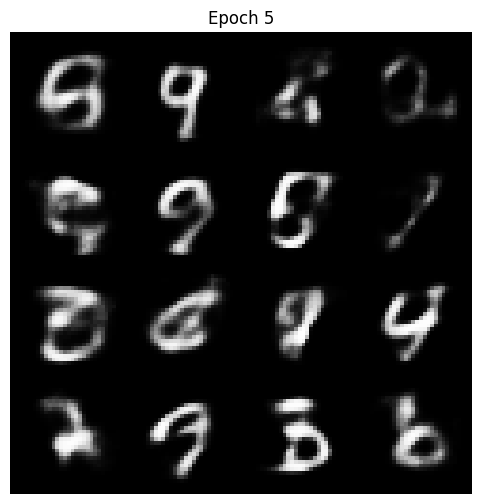

Epoch 6/20 | Loss: 108.7016
Epoch 7/20 | Loss: 107.8583
Epoch 8/20 | Loss: 107.2561
Epoch 9/20 | Loss: 106.7373
Epoch 10/20 | Loss: 106.2973


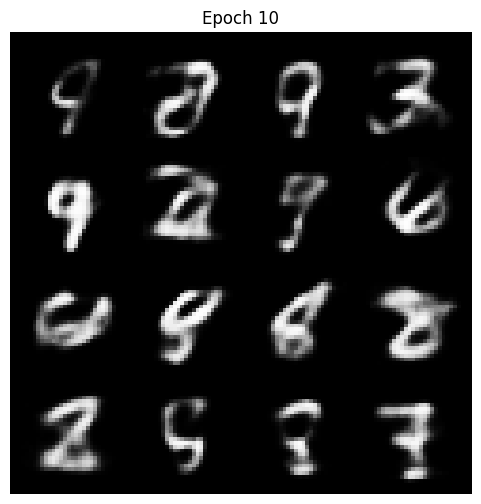

Epoch 11/20 | Loss: 105.8893
Epoch 12/20 | Loss: 105.6531
Epoch 13/20 | Loss: 105.3335
Epoch 14/20 | Loss: 105.0806
Epoch 15/20 | Loss: 104.9092


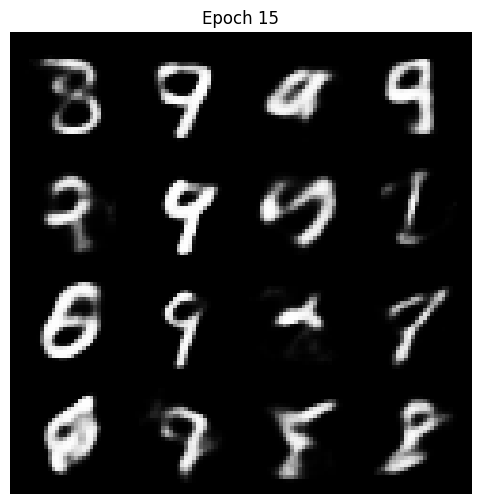

Epoch 16/20 | Loss: 104.7147
Epoch 17/20 | Loss: 104.4689
Epoch 18/20 | Loss: 104.2902
Epoch 19/20 | Loss: 104.1715
Epoch 20/20 | Loss: 104.0013


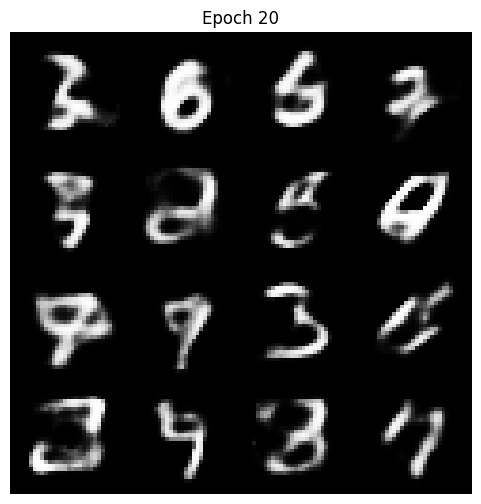

In [2]:
# VAE Model
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder - compresses image to numbers
        self.encoder = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU()
        )
        self.mu = nn.Linear(400, 20)      # mean
        self.logvar = nn.Linear(400, 20)  # variance

        # Decoder - reconstructs image from numbers
        self.decoder = nn.Sequential(
            nn.Linear(20, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x.view(-1, 784))
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# Loss function
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

# Train
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
for epoch in range(epochs):
    total_loss = 0
    for images, _ in dataloader:
        images = images.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(images)
        loss = vae_loss(recon, images, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(dataset):.4f}")

    # Show generated images every 5 epochs
    if (epoch + 1) % 5 == 0:
        model.eval()
        with torch.no_grad():
            z = torch.randn(16, 20).to(device)
            samples = model.decode(z)
            grid = make_grid(samples, nrow=4, normalize=True)
            plt.figure(figsize=(6,6))
            plt.imshow(grid.permute(1,2,0).cpu(), cmap="gray")
            plt.title(f"Epoch {epoch+1}")
            plt.axis("off")
            plt.show()
        model.train()